# Case study : Multi-class keyboard prediction

In this notebook we implement the idea behind Apple successful keyboard of the first iPhone. We are going to build :
1. The training datasets from the Gutemberg Project
2. Train a multi-class logistic regression (*ie* softmax model)
3. Evaluate its performance


## Training dataset

We will work with [The Great Gastby](https://www.gutenberg.org/ebooks/64317) of Francis Scott Fitzgerald. We first need to clean the dataset a bit.
Let's start :

In [30]:
with open("GreatGatsby.txt") as file:
    text = file.read()

print(text[:200])

In my younger and more vulnerable years my father gave me some advice
that I’ve been turning over in my mind ever since.

“Whenever you feel like criticizing anyone,” he told me, “just
remember that a


For the cleaning we will keep letters and single space, with no distinction between capital letters. Let's first store all the different possibilities :

In [31]:
text = text.lower()
characters = set[str]()

for character in text:
    if character.isascii() and (character.isalpha() or character == " "):
        characters.add(character)

print(f"There is {len(characters)} different characters in the book.")
print(characters)

There is 27 different characters in the book.
{'u', 'k', 'g', 'x', 'q', 'y', 'm', 'j', 'd', 't', 'o', 'w', 'b', ' ', 'e', 'v', 'r', 'a', 'n', 'f', 'z', 'p', 'h', 'i', 'c', 's', 'l'}


Now we can filter the text :

In [32]:
length_before = len(text)
text = text.replace("\n", " ")
text = "".join(
    character for character in text
    if character in characters
)
length_after = len(text)
ratio = (length_after - length_before) / length_before
print(f"Length before : {length_before}, and after : {length_after} so a {100*ratio:.2f}% decrease")
print("The text looks like now :\n")
print(text[:200])

Length before : 268182, and after : 256375 so a -4.40% decrease
The text looks like now :

in my younger and more vulnerable years my father gave me some advice that ive been turning over in my mind ever since  whenever you feel like criticizing anyone he told me just remember that all the 


In order to build our dataset, we will work with consecutive letters with a window size of 3 : 3 letters for $X$ and the following for $y$. Applied to the text, we will have with the beginning "in my younger" :
1. $X$  = "in " and $y$ = "m"
2. $X$  = "n m" and $y$ = "y"
3. $X$  = " my" and $y$ = " "
4. $X$  = "my " and $y$ = "y"

And we keep going. 

In [33]:
window_size = 3

X = [text[i:i+window_size] for i in range(len(text) - window_size)]
y = [text[i+window_size] for i in range(len(text) - window_size)]

print(f"Dataset size: {len(X)} samples")

Dataset size: 256372 samples


$X$ is yet text only, not numerical. We need to transform it in order to use Machine Learning methods. We will use two built-in methods from scikit-learn :

* [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) : encode each modality into a digit between 0 and the number of modalities
* [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) : encode a categorical vector into a matrix with the number of columns equals to the number of modalities.

For each trigram, we will build one feature. Thus, with the previous examples, we will have one column "in ", "n m" and so on. The plan is :
1. Label encoding for each trigram
2. One Hot Encoding of each trigram (label encoded)
3. Label encoding for $y$

We have :

In [34]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


label_encoder = LabelEncoder()
label_encoder.fit(list(characters))

X_int = np.array([[label_encoder.transform(list(trigram))] for trigram in X]).squeeze()
X_int = X_int.reshape(-1, window_size)

ohe = OneHotEncoder(sparse_output=False)
X_encoded = ohe.fit_transform(X_int)

y_encoded = label_encoder.transform(list(y))

print(f"X shape: {X_encoded.shape}")
print(f"y shape: {y_encoded.shape}")

X shape: (256372, 81)
y shape: (256372,)


## Training

In order to train the model, we need a train and a test dataset. We can't randomly split the full dataset as trigrams heavily overlap. Thus we split according to the natural order of the book :

In [35]:
split = int(0.7 * len(X_encoded))

X_train, X_test = X_encoded[:split], X_encoded[split:]
y_train, y_test = y_encoded[:split], y_encoded[split:]

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 179460
Test size: 76912


Time for training ! We will use the [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) class with the parameter `multi_class` set to *multinomial*. Note that it will produce an error as this will be removed and set as default in the following versions.

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class="multinomial", max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Performances

We now need to measure performance. We will use the [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) and a way to [display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) it nicely.

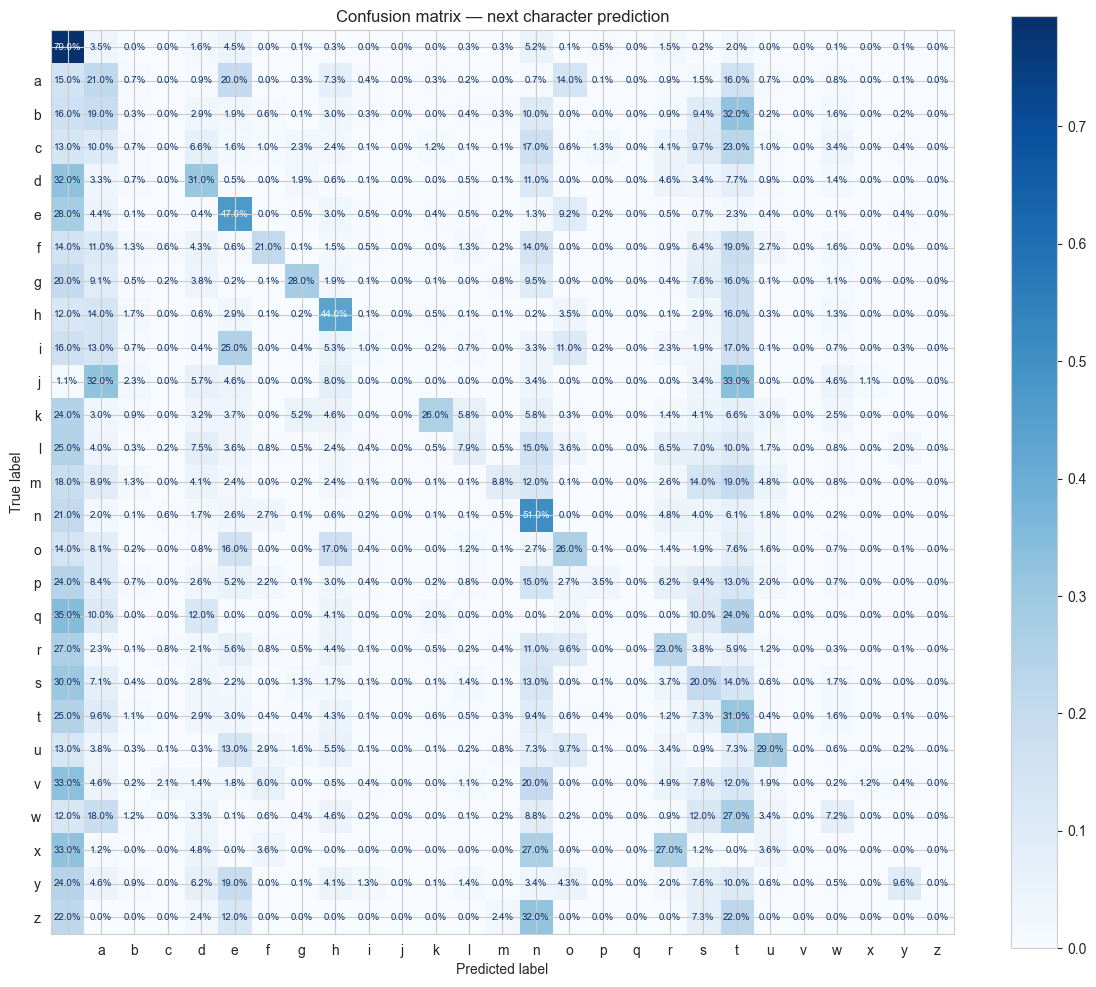

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style(style="whitegrid")
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize="true")
labels = label_encoder.classes_

fig, ax = plt.subplots(figsize=(12, 10))
matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
matrix.plot(ax=ax, colorbar=True, cmap="Blues")

for text_obj in matrix.text_.ravel():
    text_obj.set_text(f"{float(text_obj.get_text()):.1%}")
    text_obj.set_fontsize(7)

plt.title("Confusion matrix — next character prediction")
plt.tight_layout()
plt.show()

To have classical metrics for multi-class prediction, we can use the [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) :

In [38]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=labels)
print(report)

              precision    recall  f1-score   support

                   0.49      0.79      0.60     15462
           a       0.18      0.21      0.19      5069
           b       0.01      0.00      0.00       943
           c       0.00      0.00      0.00      1336
           d       0.38      0.31      0.34      2959
           e       0.41      0.47      0.44      7460
           f       0.45      0.21      0.28      1257
           g       0.53      0.28      0.37      1438
           h       0.40      0.44      0.42      4026
           i       0.22      0.01      0.02      4198
           j       0.00      0.00      0.00        87
           k       0.46      0.26      0.33       591
           l       0.33      0.08      0.13      2416
           m       0.44      0.09      0.15      1573
           n       0.31      0.51      0.38      4158
           o       0.32      0.26      0.29      4776
           p       0.17      0.03      0.06       889
           q       0.00    

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

What really matters for our problem is the top-$k$ accuracy, in plain english : how many keys should we enlarge ? But as the problem is clearly imbalance, we have two options :
1. Don't weight the accuracy : this is a ML error, but according to the user it is actually less impact
2. Weight the accuracy : this is fairness across each letters, and ML by the book

We will display the two curves, for a few values of $k$ :

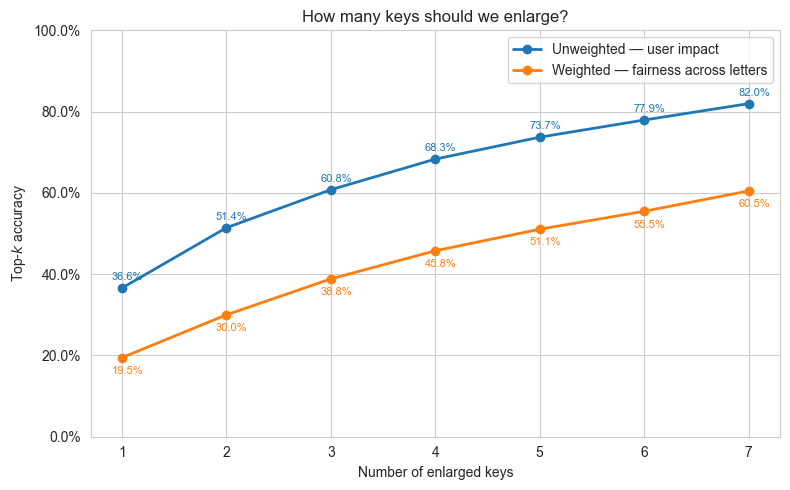

In [39]:
from collections import Counter
from sklearn.metrics import top_k_accuracy_score

class_counts = Counter(y_train)
sample_weights = np.array([1 / class_counts[y] for y in y_test])

y_proba = model.predict_proba(X_test)

k_values = range(1, 8)
top_k_scores = [top_k_accuracy_score(y_test, y_proba, k=k) for k in k_values]
top_k_scores_weighted = [
    top_k_accuracy_score(y_test, y_proba, k=k, sample_weight=sample_weights)
    for k in k_values
]


fig, ax = plt.subplots(figsize=(8, 5))

plt.plot(k_values, top_k_scores, marker='o', linewidth=2, color=sns.color_palette()[0], label='Unweighted — user impact')
plt.plot(k_values, top_k_scores_weighted, marker='o', linewidth=2, color=sns.color_palette()[1], label='Weighted — fairness across letters')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

for k, (s1, s2) in enumerate(zip(top_k_scores, top_k_scores_weighted), start=1):
    plt.annotate(f"{s1:.1%}", xy=(k, s1), xytext=(k-0.1, s1 + 0.02), 
                fontsize=8, color=sns.color_palette()[0])
    plt.annotate(f"{s2:.1%}", xy=(k, s2), xytext=(k - 0.1, s2 - 0.04), 
                fontsize=8, color=sns.color_palette()[1])

plt.ylim(0, 1)
plt.xlabel("Number of enlarged keys")
plt.ylabel(r"Top-$k$ accuracy")
plt.title("How many keys should we enlarge?")
plt.legend()
plt.tight_layout()
plt.show()